# 01 — Exploración del corpus (Fase 1)

Prueba interactiva de `src/corpus.py`. El objetivo es validar tres cosas antes de
pasar a la Fase 2 (vocabulario):

1. Que el corpus comprimido se lee **por streaming**, sin descomprimirlo a disco.
2. Que `tokenize()` produce tokens razonables para el español del SBWC.
3. Tener las estadísticas descriptivas básicas (oraciones, tokens, tipos,
   longitud de oración) para dimensionar las fases siguientes.

Todo el código real vive en `src/corpus.py`; aquí solo se lo invoca.

In [1]:
import sys
import time
from pathlib import Path

import yaml

# Permite importar `src` cuando el notebook se ejecuta desde notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.corpus import (
    corpus_stats,
    count_lines,
    stream_sentences,
    stream_tokens,
    tokenize,
)

CONFIG = yaml.safe_load((ROOT / "configs" / "base.yaml").read_text(encoding="utf-8"))
CORPUS_PATH = ROOT / CONFIG["corpus_path"]
TOK = CONFIG["tokenizer"]  # opciones de tokenización de la config base

print("config:", CONFIG["name"])
print("corpus:", CORPUS_PATH)
print("existe:", CORPUS_PATH.exists(), "| tamaño: %.2f GB" % (CORPUS_PATH.stat().st_size / 1024**3))
print("tokenizer:", TOK)

config: base_5k_50_2
corpus: c:\Users\Carlo\Documents\Maestria\Proyecto_T\projects_claude\proyecto_cbow\data\raw\sbwce.clean.txt.bz2
existe: True | tamaño: 2.77 GB
tokenizer: {'lowercase': True, 'number_token': '<NUM>', 'min_length': 1}


In [7]:
print(Path.cwd())

c:\Users\Carlo\Documents\Maestria\Proyecto_T\projects_claude\proyecto_cbow\notebooks


## 1. Lectura cruda: primeras oraciones

`stream_sentences` es un generador; con `limit` se cortan las primeras N líneas
sin tocar el resto del archivo (la lectura es perezosa).

In [2]:
for i, sentence in enumerate(stream_sentences(CORPUS_PATH, sample_fraction=1.0, limit=10), start=1):
    print(f"{i:2d}. {sentence[:110]}")

 1. En el nombre de Alá el Compasivo el Misericordioso
 2. Alabado sea Alá Señor del universo
 3. Dueño del día del Juicio
 4. A Ti solo servimos y a Ti solo imploramos ayuda
 5. Dirígenos por la vía recta
 6. la vía de los que Tú has agraciado no de los que han incurrido en la ira ni de los extraviados
 7. Ésta es la Escritura exenta de dudas como dirección para los temerosos de Alá
 8. que creen en lo oculto hacen la azalá y dan limosna de lo que les hemos proveído
 9. creen en lo que se te ha revelado a ti y antes de ti y están convencidos de la otra vida
10. Ésos son los dirigidos por su Señor y ésos los que prosperarán


Confirmamos que el archivo es UTF-8 válido (las tildes y la `ñ` se leen bien) y
que hay **una oración por línea, sin puntuación de cierre**.

## 2. Tokenización

`tokenize()` normaliza a NFC, borra guiones suaves, unifica apóstrofes, pasa a
minúsculas y colapsa cada número en `<NUM>`. Comparamos oración cruda vs tokens.

In [3]:
for sentence in stream_sentences(CORPUS_PATH, limit=5):
    print("CRUDA :", sentence[:100])
    print("TOKENS:", tokenize(sentence, **TOK))
    print("-" * 80)

CRUDA : En el nombre de Alá el Compasivo el Misericordioso
TOKENS: ['en', 'el', 'nombre', 'de', 'alá', 'el', 'compasivo', 'el', 'misericordioso']
--------------------------------------------------------------------------------
CRUDA : Alabado sea Alá Señor del universo
TOKENS: ['alabado', 'sea', 'alá', 'señor', 'del', 'universo']
--------------------------------------------------------------------------------
CRUDA : Dueño del día del Juicio
TOKENS: ['dueño', 'del', 'día', 'del', 'juicio']
--------------------------------------------------------------------------------
CRUDA : A Ti solo servimos y a Ti solo imploramos ayuda
TOKENS: ['a', 'ti', 'solo', 'servimos', 'y', 'a', 'ti', 'solo', 'imploramos', 'ayuda']
--------------------------------------------------------------------------------
CRUDA : Dirígenos por la vía recta
TOKENS: ['dirígenos', 'por', 'la', 'vía', 'recta']
--------------------------------------------------------------------------------


### Casos borde

El corpus está "limpio" pero conserva dígitos, `.`, `/`, `,`, paréntesis y
guiones suaves incrustados. Estos casos verifican cada decisión del tokenizador.

In [5]:
CASOS = [
    ("puntuación residual", "(hola) [chau] -- ¿qué? ¡sí!"),
    ("decimales y fechas", "El PIB creció 3.5% en 1999 y cayó 2,1 en 2000"),
    ("fecha con barras", "el acuerdo del 12/03/1998"),
    ("guion suave", "el r\u00e9\u00adgimen militar"),
    ("apóstrofe tipográfico", "la novela de O\u2019Donnell y de O'Hara"),
    ("palabra con guion", "un acuerdo franco-alemán"),
    ("línea vacía", "   "),
]

for nombre, texto in CASOS:
    print(f"{nombre:24s} {texto!r}")
    print(f"{'':24s} -> {tokenize(texto, **TOK)}")

puntuación residual      '(hola) [chau] -- ¿qué? ¡sí!'
                         -> ['hola', 'chau', 'qué', 'sí']
decimales y fechas       'El PIB creció 3.5% en 1999 y cayó 2,1 en 2000'
                         -> ['el', 'pib', 'creció', '<NUM>', 'en', '<NUM>', 'y', 'cayó', '<NUM>', 'en', '<NUM>']
fecha con barras         'el acuerdo del 12/03/1998'
                         -> ['el', 'acuerdo', 'del', '<NUM>']
guion suave              'el ré\xadgimen militar'
                         -> ['el', 'régimen', 'militar']
apóstrofe tipográfico    "la novela de O’Donnell y de O'Hara"
                         -> ['la', 'novela', 'de', "o'donnell", 'y', 'de', "o'hara"]
palabra con guion        'un acuerdo franco-alemán'
                         -> ['un', 'acuerdo', 'franco-alemán']
línea vacía              '   '
                         -> []


Puntos a verificar arriba:

- La puntuación actúa como separador y **no** genera tokens.
- `3.5` y `12/03/1998` producen **un solo** `<NUM>` (no ocupan varias posiciones
  de la ventana de contexto).
- El guion suave se elimina y la palabra queda entera.
- `O’Donnell` y `O'Hara` usan el mismo apóstrofe, así que no se duplican tipos.
- Los guiones *entre* palabras sí se conservan (`franco-alemán`).

In [6]:
# Los números también se pueden descartar en vez de normalizar (number_token=None)
texto = "en 1999 vivían 25 millones"
print("con <NUM> :", tokenize(texto, number_token="<NUM>"))
print("sin números:", tokenize(texto, number_token=None))
print("min_length=3:", tokenize("a mi me da lo mismo", min_length=3))

con <NUM> : ['en', '<NUM>', 'vivían', '<NUM>', 'millones']
sin números: ['en', 'vivían', 'millones']
min_length=3: ['mismo']


## 3. Streaming ya tokenizado

`stream_tokens` es el generador que consumirán las fases siguientes
(vocabulario y pares contexto-target): entrega listas de tokens y omite las
oraciones que quedan vacías.

In [6]:
for tokens in stream_tokens(CORPUS_PATH, limit=5, **TOK):
    print(len(tokens), tokens[:15])

9 ['en', 'el', 'nombre', 'de', 'alá', 'el', 'compasivo', 'el', 'misericordioso']
6 ['alabado', 'sea', 'alá', 'señor', 'del', 'universo']
5 ['dueño', 'del', 'día', 'del', 'juicio']
10 ['a', 'ti', 'solo', 'servimos', 'y', 'a', 'ti', 'solo', 'imploramos', 'ayuda']
5 ['dirígenos', 'por', 'la', 'vía', 'recta']


## 4. Muestreo reproducible

`sample_fraction` conserva cada línea con esa probabilidad. Depende solo de
`seed`, así que dos corridas con la misma semilla dan exactamente la misma
muestra.

> **Nota de rendimiento:** `sample_fraction` reduce las oraciones *producidas*,
> pero igual hay que descomprimir el archivo entero para llegar al final. Para
> pruebas rápidas conviene combinarlo con `limit`, que corta de inmediato.

In [7]:
a = list(stream_sentences(CORPUS_PATH, 0.5, limit=5, seed=CONFIG["seed"]))
b = list(stream_sentences(CORPUS_PATH, 0.5, limit=5, seed=CONFIG["seed"]))
c = list(stream_sentences(CORPUS_PATH, 0.5, limit=5, seed=CONFIG["seed"] + 1))

print("misma semilla -> misma muestra:", a == b)
print("otra semilla  -> otra muestra :", a != c)
for s in a:
    print("  ", s[:80])

misma semilla -> misma muestra: True
otra semilla  -> otra muestra : True
   Alabado sea Alá Señor del universo
   Dueño del día del Juicio
   A Ti solo servimos y a Ti solo imploramos ayuda
   que creen en lo oculto hacen la azalá y dan limosna de lo que les hemos proveído
   creen en lo que se te ha revelado a ti y antes de ti y están convencidos de la o


## 5. Estadísticas descriptivas sobre una muestra

`corpus_stats` recorre el corpus (o un prefijo con `limit`) y devuelve conteos
agregados más el histograma de longitudes de oración. Con `limit=200_000`
tarda unos pocos segundos.

In [7]:
N_MUESTRA = 200_000

t0 = time.time()
stats = corpus_stats(CORPUS_PATH, limit=N_MUESTRA, **TOK)
elapsed = time.time() - t0

hist = stats.pop("length_histogram")
for k, v in stats.items():
    print(f"{k:26s} {v:,.2f}" if isinstance(v, float) else f"{k:26s} {v:,}")
print(f"{'segundos':26s} {elapsed:,.1f}")
print(f"{'oraciones/segundo':26s} {stats['n_sentences'] / elapsed:,.0f}")

n_sentences                200,000
n_tokens                   5,362,811
n_types                    107,159
avg_tokens_per_sentence    26.81
min_sentence_length        1
max_sentence_length        537
segundos                   7.4
oraciones/segundo          27,105


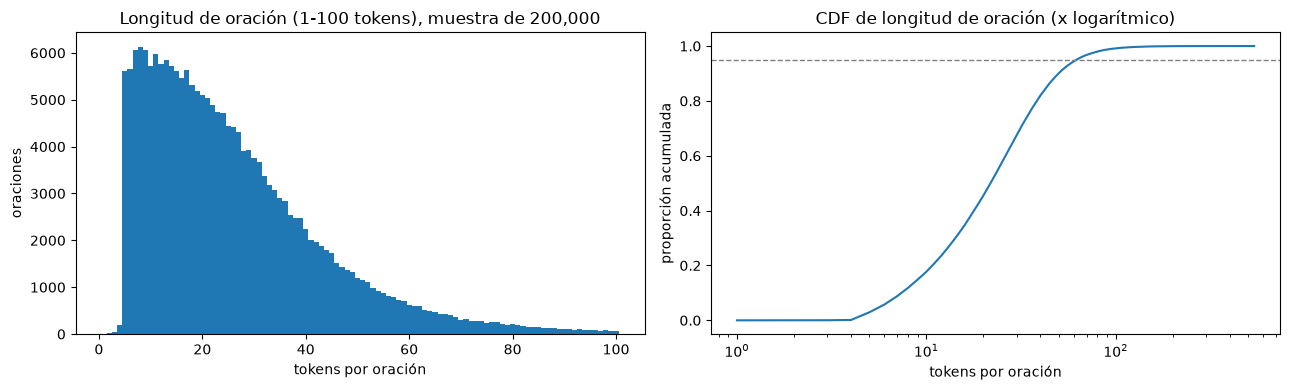

percentil 95 de longitud: 62 tokens
oraciones con <= 2 tokens: 23 (0.01%)


In [9]:
import matplotlib.pyplot as plt

longitudes = sorted(hist)
frecuencias = [hist[n] for n in longitudes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(longitudes[:100], frecuencias[:100], width=1.0)
axes[0].set_title(f"Longitud de oración (1-100 tokens), muestra de {N_MUESTRA:,}")
axes[0].set_xlabel("tokens por oración")
axes[0].set_ylabel("oraciones")

acumulado = 0
total = sum(frecuencias)
cdf = []
for n in longitudes:
    acumulado += hist[n]
    cdf.append(acumulado / total)
axes[1].plot(longitudes, cdf)
axes[1].axhline(0.95, ls="--", c="gray", lw=1)
axes[1].set_xscale("log")
axes[1].set_title("CDF de longitud de oración (x logarítmico)")
axes[1].set_xlabel("tokens por oración")
axes[1].set_ylabel("proporción acumulada")

plt.tight_layout()
plt.show()

p95 = next(n for n, p in zip(longitudes, cdf) if p >= 0.95)
cortas = sum(hist[n] for n in longitudes if n <= 2)
print(f"percentil 95 de longitud: {p95} tokens")
print(f"oraciones con <= 2 tokens: {cortas:,} ({cortas / total:.2%})")

Las oraciones muy cortas importan para la Fase 3: con `context_size=2` una
oración de 1-2 tokens genera pocos pares o ninguno, según cómo se maneje el
borde de la ventana.

## 6. Conteo total de líneas del corpus

Reproducible desde Python (sin `wc -l`), pero hay que descomprimir los ~3 GB
completos: son varios minutos. Por eso está detrás de un interruptor.

In [10]:
EJECUTAR_CONTEO_COMPLETO = False  # ponerlo en True para recorrer el corpus entero

if EJECUTAR_CONTEO_COMPLETO:
    t0 = time.time()
    total_lineas = count_lines(CORPUS_PATH, progress=True)
    print(f"total de líneas: {total_lineas:,} en {(time.time() - t0) / 60:.1f} min")
else:
    # Estimación a partir del throughput medido arriba, solo como referencia.
    print("Conteo completo desactivado. Alternativa por línea de comandos:")
    print("  python -m src.corpus --count-lines")

Conteo completo desactivado. Alternativa por línea de comandos:
  python -m src.corpus --count-lines


## Conclusiones de la Fase 1

- La lectura por streaming del `.bz2` funciona: nunca se descomprime a disco ni
  se carga el corpus en memoria.
- `tokenize()` maneja correctamente acentos, `ñ`, apóstrofes, guiones (suaves e
  internos), puntuación residual y números.
- El throughput medido alcanza para las fases siguientes; aun así, conviene usar
  `limit` / `sample_fraction` mientras se itera.

**Siguiente paso:** Fase 2 — `src/vocabulary.py` (conteo de frecuencias por
streaming, top-N palabras, `<UNK>` y subsampling de Mikolov).